# Banking Transaction Analysis Project

##### This project focuses on Banking Transaction Analysis using PySpark to process and analyze large-scale banking data efficiently. It helps in identifying transaction patterns, calculating balances, and detecting unusual or suspicious activities. The analysis provides useful insights for better financial monitoring and decision-making.

## Spark Session

In [6]:
from pyspark.sql import SparkSession

In [7]:
spark = SparkSession.builder \
    .appName("Banking Transaction Analysis") \
    .getOrCreate()

In [8]:
print("Spark is working successfully!")

Spark is working successfully!


# Read CSV File

In [ ]:
df = spark.read.csv( "C:\\Users\\amnai\\Documents\\Banking_Transaction_Analysis\\Dataset\\Bank Transaction Dataset for Fraud Detection .csv"
    ,
    header=True,
    inferSchema=True
)

# Display Dataset

In [7]:
df.show()

+-------------+---------+-----------------+----------------+---------------+-------------+--------+---------------+----------+-------+-----------+------------------+-------------------+-------------+--------------+
|TransactionID|AccountID|TransactionAmount| TransactionDate|TransactionType|     Location|DeviceID|     IP Address|MerchantID|Channel|CustomerAge|CustomerOccupation|TransactionDuration|LoginAttempts|AccountBalance|
+-------------+---------+-----------------+----------------+---------------+-------------+--------+---------------+----------+-------+-----------+------------------+-------------------+-------------+--------------+
|     TX000001|  AC00128|            14.09| 4/11/2023 16:29|          Debit|    San Diego| D000380| 162.198.218.92|      M015|    ATM|         70|            Doctor|                 81|            1|       5112.21|
|     TX000002|  AC00455|           376.24| 6/27/2023 16:44|          Debit|      Houston| D000051|    13.149.61.4|      M052|    ATM|      

# Check Dataset Structure

In [8]:
df.printSchema()

root
 |-- TransactionID: string (nullable = true)
 |-- AccountID: string (nullable = true)
 |-- TransactionAmount: double (nullable = true)
 |-- TransactionDate: string (nullable = true)
 |-- TransactionType: string (nullable = true)
 |-- Location: string (nullable = true)
 |-- DeviceID: string (nullable = true)
 |-- IP Address: string (nullable = true)
 |-- MerchantID: string (nullable = true)
 |-- Channel: string (nullable = true)
 |-- CustomerAge: integer (nullable = true)
 |-- CustomerOccupation: string (nullable = true)
 |-- TransactionDuration: integer (nullable = true)
 |-- LoginAttempts: integer (nullable = true)
 |-- AccountBalance: double (nullable = true)



# Count Total Transactions

In [9]:
df.count()

50000

# Remove Null Values

In [10]:
df = df.dropna()

# Remove Duplicate Records

In [11]:
df = df.dropDuplicates()

# Highest Transactions

In [17]:
from pyspark.sql.functions import col

In [18]:
df.orderBy(
    col("TransactionAmount").desc()
).show(10)

+-------------+---------+-----------------+---------------+---------------+-----------+--------+---------------+----------+-------+-----------+------------------+-------------------+-------------+--------------+
|TransactionID|AccountID|TransactionAmount|TransactionDate|TransactionType|   Location|DeviceID|     IP Address|MerchantID|Channel|CustomerAge|CustomerOccupation|TransactionDuration|LoginAttempts|AccountBalance|
+-------------+---------+-----------------+---------------+---------------+-----------+--------+---------------+----------+-------+-----------+------------------+-------------------+-------------+--------------+
|     TX039963|  AC00423|          2060.59|      11/6/2021|          Debit|   Portland| D000191|207.157.126.125|      M033|    ATM|         30|            Doctor|                161|            1|      11090.24|
|     TX022803|  AC00179|          2026.44|      3/30/2021|         Credit|   Columbus| D000246|  141.121.30.32|      M012| Online|         62|         

# Average Transaction Amount

In [19]:
from pyspark.sql.functions import avg

In [44]:
df.select(
    avg("TransactionAmount")
).show()

+----------------------+
|avg(TransactionAmount)|
+----------------------+
|     297.8722137999996|
+----------------------+



# Suspicious Transactions List

In [17]:
threshold = 2000

fraud_df = df.filter(
    ( df["TransactionAmount"]) > threshold
)

fraud_df.show()

+-------------+---------+-----------------+---------------+---------------+-----------+--------+---------------+----------+-------+-----------+------------------+-------------------+-------------+--------------+
|TransactionID|AccountID|TransactionAmount|TransactionDate|TransactionType|   Location|DeviceID|     IP Address|MerchantID|Channel|CustomerAge|CustomerOccupation|TransactionDuration|LoginAttempts|AccountBalance|
+-------------+---------+-----------------+---------------+---------------+-----------+--------+---------------+----------+-------+-----------+------------------+-------------------+-------------+--------------+
|     TX022803|  AC00179|          2026.44|      3/30/2021|         Credit|   Columbus| D000246|  141.121.30.32|      M012| Online|         62|            Doctor|                 83|            1|      11498.01|
|     TX016716|  AC00423|          2014.32|      7/15/2021|          Debit|   Portland| D000191|207.157.126.125|      M033|    ATM|         30|         

# Most Active Customers

In [23]:
df.groupBy("AccountID") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(10)

+---------+-----+
|AccountID|count|
+---------+-----+
|  AC00363|  249|
|  AC00202|  241|
|  AC00460|  238|
|  AC00362|  233|
|  AC00480|  230|
|  AC00304|  225|
|  AC00241|  211|
|  AC00225|  208|
|  AC00257|  207|
|  AC00297|  201|
+---------+-----+
only showing top 10 rows


# Total Balance

In [20]:
from pyspark.sql.functions import sum

In [21]:
balance_df = df.groupBy("AccountID") \
    .agg(sum("TransactionAmount").alias("TotalBalance"))

balance_df.show()

+---------+------------------+
|AccountID|      TotalBalance|
+---------+------------------+
|  AC00039|42029.479999999996|
|  AC00169|3630.2699999999995|
|  AC00364|2931.5399999999995|
|  AC00379|            9577.1|
|  AC00368|24974.619999999995|
|  AC00223|          18649.41|
|  AC00428|24575.989999999998|
|  AC00002|          44530.62|
|  AC00069|40212.600000000006|
|  AC00235|          24867.03|
|  AC00074|           5603.57|
|  AC00024|27989.879999999997|
|  AC00492|          16059.05|
|  AC00053|          17575.72|
|  AC00332|40572.630000000005|
|  AC00027|11137.159999999998|
|  AC00092|          40165.61|
|  AC00313|           15109.8|
|  AC00061|16241.219999999998|
|  AC00145|          26019.51|
+---------+------------------+
only showing top 20 rows


# Visualizations


In [26]:
import matplotlib.pyplot as plt

# Transaction Analysis

In [ ]:
transaction_data = df.groupBy(
    "TransactionType"
).count().toPandas()

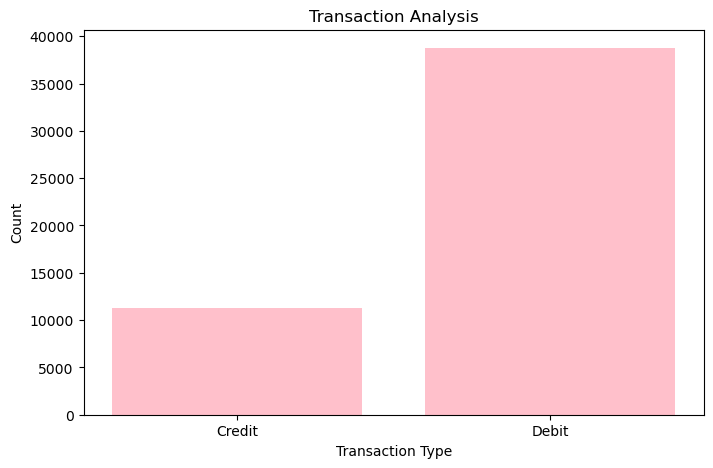

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    transaction_data["TransactionType"],
    transaction_data["count"] ,
     color="pink" 
)


plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.title("Transaction Analysis")

plt.show()

# Top Accounts by Total Balance

In [29]:
from pyspark.sql.functions import sum

balance_graph = df.groupBy("AccountID") \
    .agg(
        sum("TransactionAmount").alias("TotalBalance")
    ) \
    .orderBy("TotalBalance", ascending=False) \
    .limit(10)
balance_pd = balance_graph.toPandas()

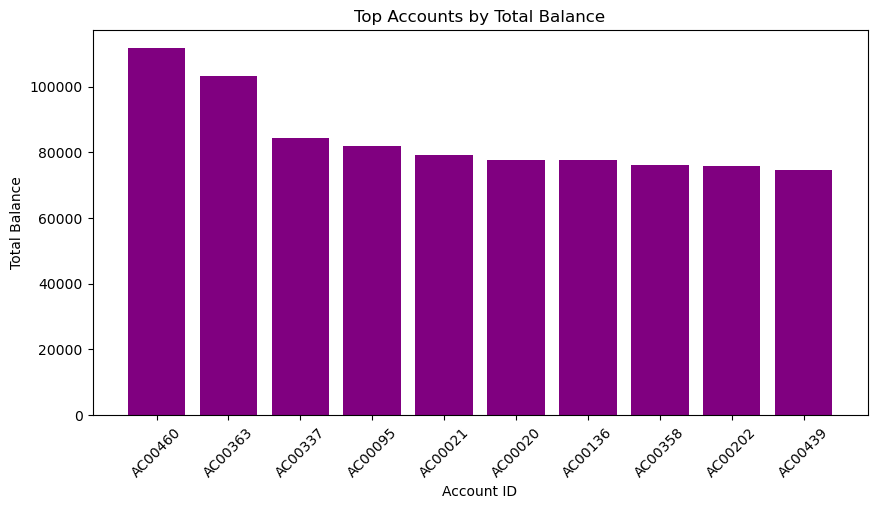

In [32]:
plt.figure(figsize=(10,5))

plt.bar(
    balance_pd["AccountID"],
    balance_pd["TotalBalance"] , 
    color = "purple"
    
)

plt.xlabel("Account ID")
plt.ylabel("Total Balance")
plt.title("Top Accounts by Total Balance")

plt.xticks(rotation=45)

plt.show()